In [1]:
!git clone https://github.com/niaz1971/BOOK_CHAPTERS.git

Cloning into 'BOOK_CHAPTERS'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 28 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 8.88 MiB | 13.33 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
cd BOOK_CHAPTERS/'Deep Transfer Learning Paradigms for High-Efficiency Smart Waste Sorting Systems'

/content/BOOK_CHAPTERS/Deep Transfer Learning Paradigms for High-Efficiency Smart Waste Sorting Systems


In [3]:
!ls

kaggle.json


In [4]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d asdasdasasdas/garbage-classification

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f4525b9010c8e9631233c715e32f5c101adb211c56531d4d740e08777ab2d5d1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 165MB/s]



In [5]:
!ls

garbage-classification.zip  kaggle.json


In [6]:
!unzip -q garbage-classification.zip
!rm garbage-classification.zip
!rm kaggle.json

In [7]:
!ls

'garbage classification'	       one-indexed-files-notrash_val.txt
'Garbage classification'	       one-indexed-files.txt
 one-indexed-files-notrash_test.txt    zero-indexed-files.txt
 one-indexed-files-notrash_train.txt


In [8]:
cd garbage classification

/content/BOOK_CHAPTERS/Deep Transfer Learning Paradigms for High-Efficiency Smart Waste Sorting Systems/garbage classification


In [9]:
!ls

'Garbage classification'


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import random
import glob

# **Define dataset paths**


In [11]:
DATA_DIR = "Garbage classification"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# **Display random sample images from the dataset**


Classes: ['paper', 'metal', 'glass', 'cardboard', 'trash', 'plastic']


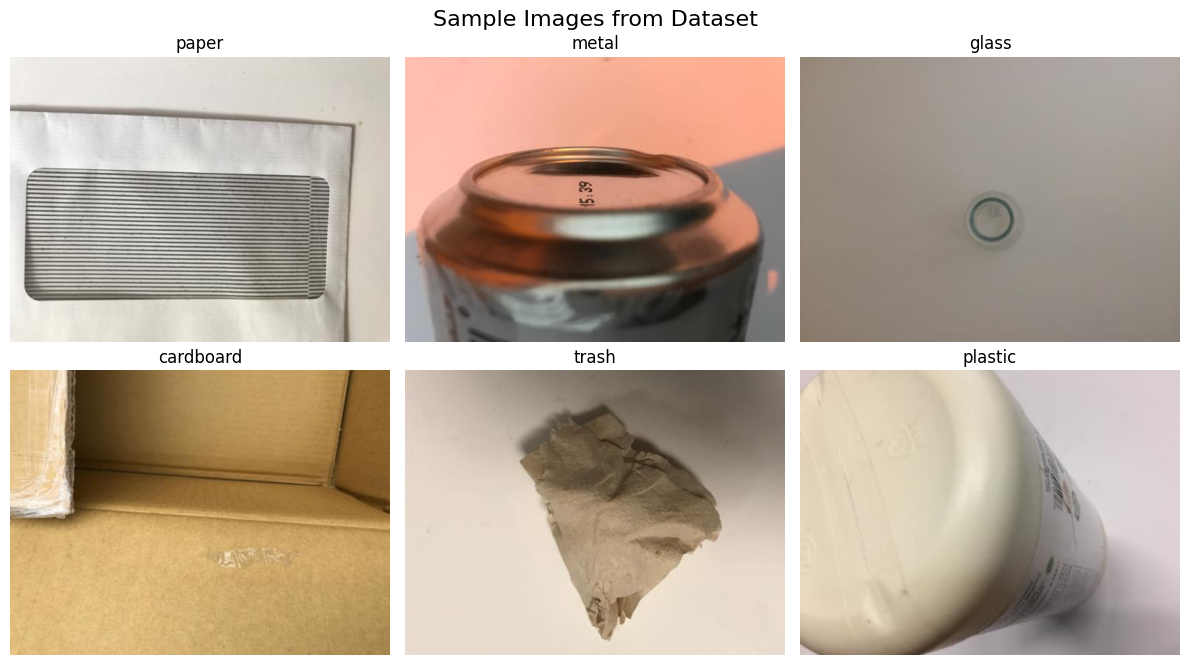

In [12]:
categories = os.listdir(DATA_DIR)
print("Classes:", categories)

plt.figure(figsize=(12, 10))
for i, category in enumerate(categories[:9]):
    folder = os.path.join(DATA_DIR, category)
    img_path = random.choice(glob.glob(folder + "/*.*"))
    img = plt.imread(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
plt.suptitle("Sample Images from Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# **Data generators with data augmentation**


In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

num_classes = len(train_gen.class_indices)
print("Number of classes:", num_classes)
print("Class mapping:", train_gen.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Number of classes: 6
Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


# **Build MobileNetV2 model with ImageNet weights**


In [14]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Train model**


In [15]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 990ms/step - accuracy: 0.5697 - loss: 1.1654 - val_accuracy: 0.6541 - val_loss: 0.9010 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 516ms/step - accuracy: 0.7154 - loss: 0.7641 - val_accuracy: 0.6998 - val_loss: 0.7625 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 510ms/step - accuracy: 0.7510 - loss: 0.6608 - val_accuracy: 0.7217 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 486ms/step - accuracy: 0.7762 - loss: 0.6161 - val_accuracy: 0.7157 - val_loss: 0.7459 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 509ms/step - accuracy: 0.7930 - loss: 0.5559 - val_accuracy: 0.7137 - val_loss: 0.7031 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 490ms/step - accuracy: 0.8009 - loss: 0.5187 - val_accuracy: 0.7237 - val_loss: 0.7690 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 508ms/step - accuracy: 0.8127 - loss: 0.

# **Plot accuracy and loss curves**


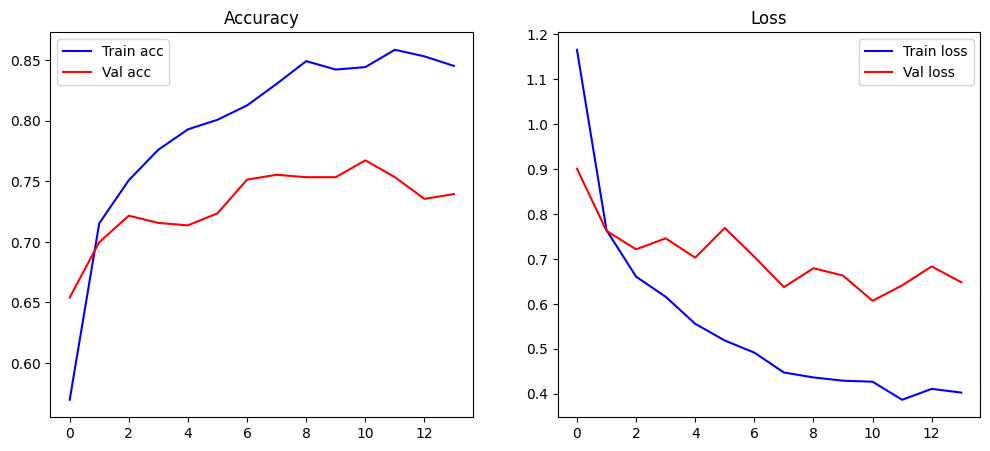

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'b', label='Train acc')
plt.plot(history.history['val_accuracy'], 'r', label='Val acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'b', label='Train loss')
plt.plot(history.history['val_loss'], 'r', label='Val loss')
plt.legend(); plt.title("Loss")
plt.show()

# **Display Model Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


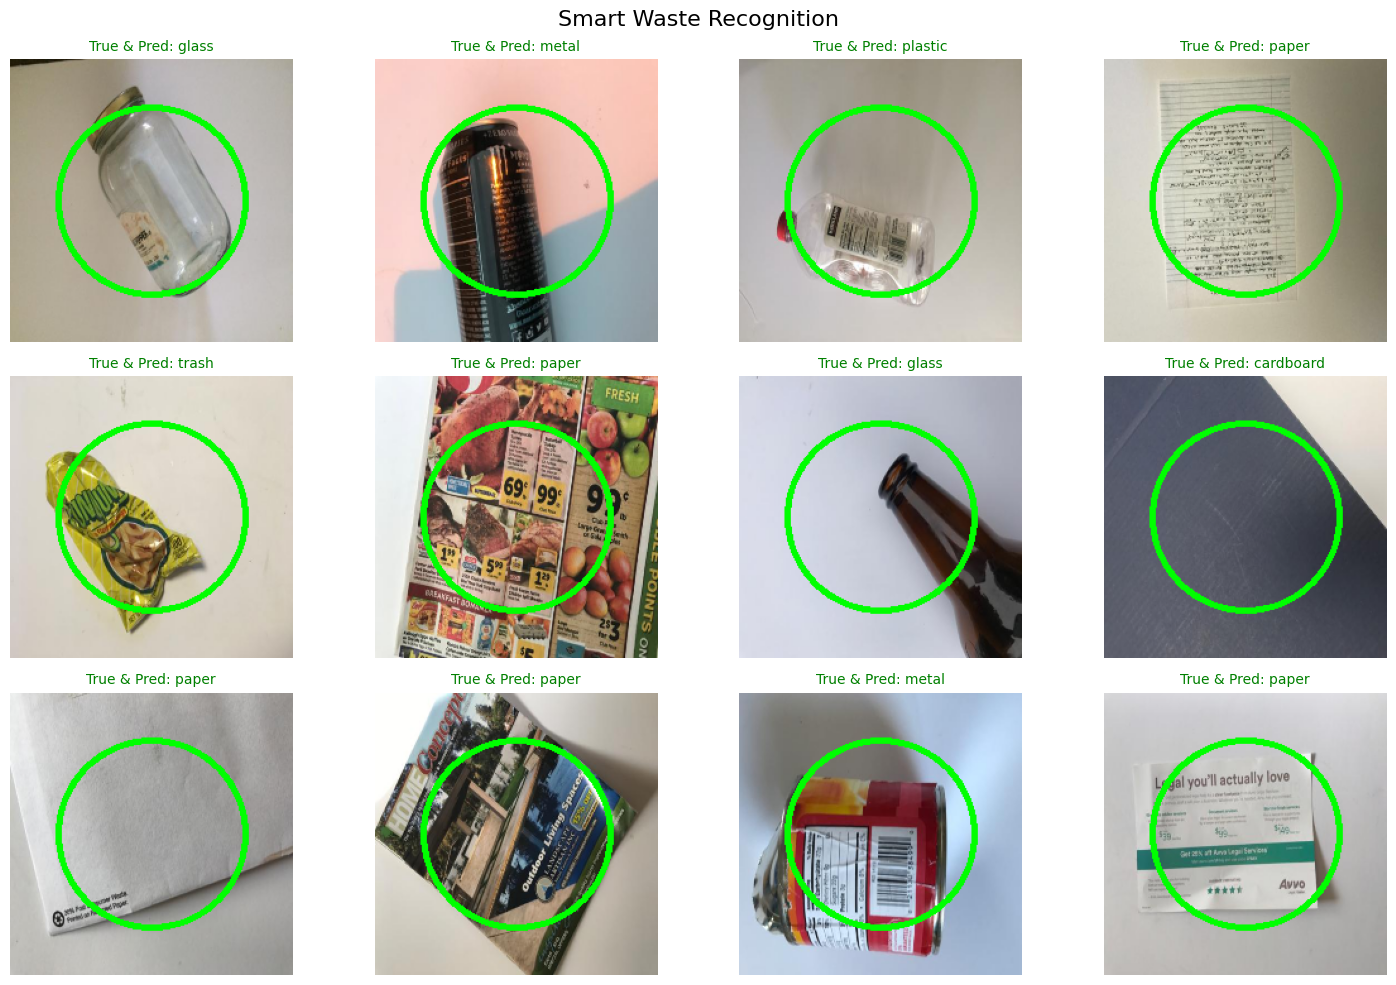

In [17]:
class_labels = list(train_gen.class_indices.keys())

sample_paths = random.sample(val_gen.filepaths, 20)

correct_images = []

for img_path in sample_paths:
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0))
    pred_label = class_labels[np.argmax(pred)]
    true_label = os.path.basename(os.path.dirname(img_path))

    if pred_label == true_label:
        correct_images.append((img_path, true_label, pred_label))

plt.figure(figsize=(15,10))
for i, (img_path, true_label, pred_label) in enumerate(correct_images[:12]):
    img_cv = cv2.imread(img_path)
    img_cv = cv2.cvtColor(cv2.resize(img_cv, IMG_SIZE), cv2.COLOR_BGR2RGB)

    h, w, _ = img_cv.shape
    center = (w//2, h//2)
    radius = min(h, w)//3
    cv2.circle(img_cv, center, radius, (0, 255, 0), 3)

    plt.subplot(3, 4, i+1)
    plt.imshow(img_cv)
    plt.title(f'True & Pred: {true_label}', fontsize=10, color='green')
    plt.axis('off')

plt.suptitle("Smart Waste Recognition", fontsize=16)
plt.tight_layout()
plt.show()

Generating predictions on validation data...
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 667ms/step


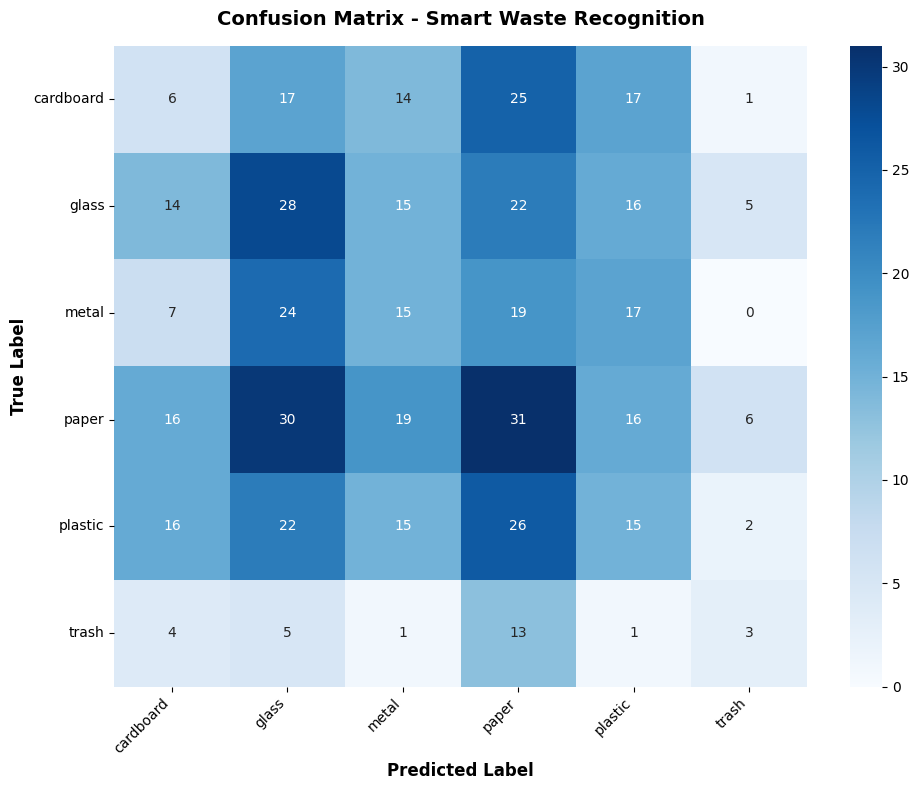


Classification Report:
              precision    recall  f1-score   support

   cardboard       0.10      0.07      0.08        80
       glass       0.22      0.28      0.25       100
       metal       0.19      0.18      0.19        82
       paper       0.23      0.26      0.24       118
     plastic       0.18      0.16      0.17        96
       trash       0.18      0.11      0.14        27

    accuracy                           0.19       503
   macro avg       0.18      0.18      0.18       503
weighted avg       0.19      0.19      0.19       503



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset validation generator to ensure correct order
val_gen.reset()

# Generate predictions for the entire validation dataset
print("Generating predictions on validation data...")
pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(val_gen.class_indices.keys())

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True
)

plt.title('Confusion Matrix - Smart Waste Recognition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Ensure validation generator is reset
val_gen.reset()

# Generate predictions if not already done
pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# Compute confusion matrix to derive Sensitivity (Recall) per class
cm = confusion_matrix(y_true, y_pred)

# Sensitivity (Recall) is True Positives / (True Positives + False Negatives)
# For each class, this is diagonal divided by row sum (true instances)
row_sums = cm.sum(axis=1)
sensitivity_per_class = np.diagonal(cm) / np.where(row_sums == 0, 1, row_sums)

# Generate classification report dictionary to extract F1-scores
report_dict = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Compile metrics into a clean summary DataFrame
metrics_data = []
for i, label in enumerate(class_labels):
    metrics_data.append({
        'Class': label,
        'Sensitivity (Recall)': sensitivity_per_class[i],
        'F1-Score': report_dict[label]['f1-score'],
        'Precision': report_dict[label]['precision'],
        'Support': report_dict[label]['support']
    })

metrics_df = pd.DataFrame(metrics_data)

# Display macro and weighted averages
print("=== Per-Class Performance Summary ===")
print(metrics_df.to_string(index=False, formatters={
    'Sensitivity (Recall)': '{:.4f}'.format,
    'F1-Score': '{:.4f}'.format,
    'Precision': '{:.4f}'.format
}))

print("\n=== Overall Metrics ===")
print(f"Macro Average F1-Score:    {report_dict['macro avg']['f1-score']:.4f}")
print(f"Weighted Average F1-Score: {report_dict['weighted avg']['f1-score']:.4f}")
print(f"Macro Average Sensitivity: {sensitivity_per_class.mean():.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step
=== Per-Class Performance Summary ===
    Class Sensitivity (Recall) F1-Score Precision  Support
cardboard               0.1250   0.1389    0.1562     80.0
    glass               0.2000   0.1802    0.1639    100.0
    metal               0.1829   0.1786    0.1744     82.0
    paper               0.2797   0.2694    0.2598    118.0
  plastic               0.1979   0.2135    0.2317     96.0
    trash               0.0741   0.0816    0.0909     27.0

=== Overall Metrics ===
Macro Average F1-Score:    0.1770
Weighted Average F1-Score: 0.1953
Macro Average Sensitivity: 0.1766


16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 429ms/step


/tmp/ipykernel_534/2239788351.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


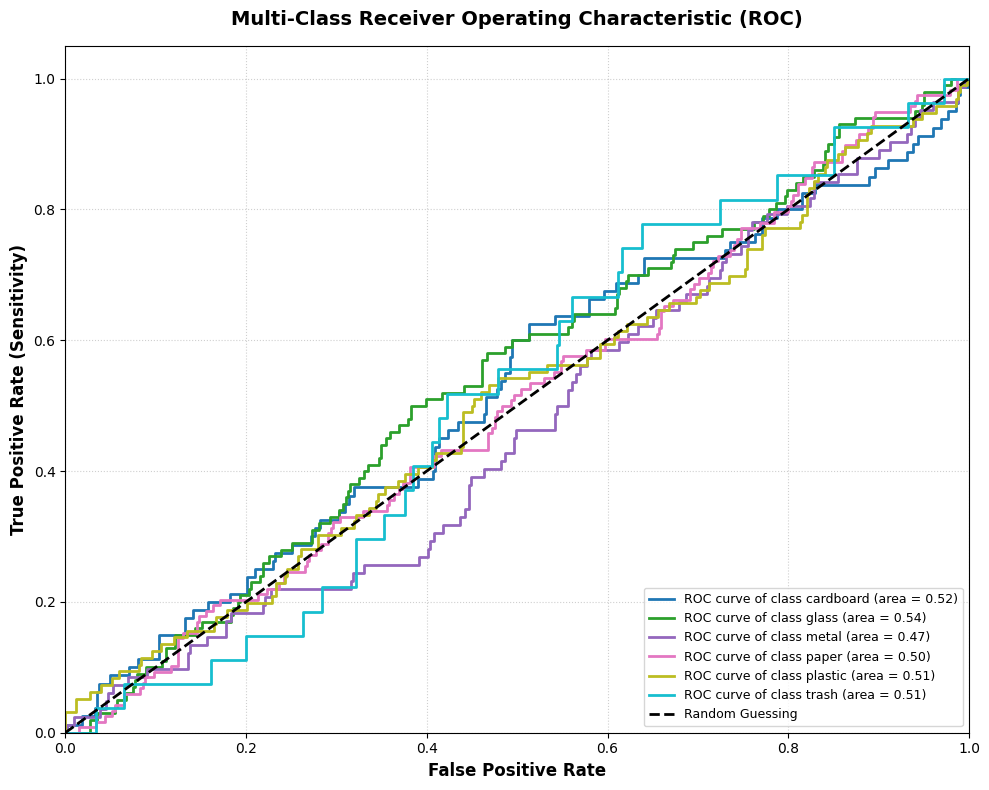

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Ensure validation generator is reset
val_gen.reset()

# Get true labels and binarize them for multi-class ROC calculation
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())
n_classes = len(class_labels)

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Get prediction probabilities if not already done
pred_probs = model.predict(val_gen, verbose=1)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

colors = plt.cm.get_cmap('tab10', n_classes)
for i, color in zip(range(n_classes), colors.colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Multi-Class Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=9, frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()